# Vansh Keserwani
## 230968290
week 6

Exercise 1: Hill-Climbing Search for Feature Selection

Objective: Find a subset of features that maximizes predictive accuracy.

Steps

State Representation

Binary vector of length n_features where 1 = feature selected, 0 = feature not selected.

Initial State

Random binary vector.

Neighbor Generation

Flip one bit at a time to create neighbors.

Evaluation Function

Use cross_val_score with Logistic Regression to evaluate accuracy.

Algorithm

Steepest-ascent hill climbing:

Evaluate all neighbors of current state.

Move to the neighbor with the highest accuracy.

Stop when no neighbor improves the current state.

Experimentation

Run multiple times with different random initial states to avoid local maxima.

In [4]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target
n_features = X.shape[1]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Evaluation function
def evaluate(state):
    selected_features = [i for i, bit in enumerate(state) if bit == 1]
    if not selected_features:
        return 0
    X_subset = X_scaled[:, selected_features]
    model = LogisticRegression(max_iter=1000, solver='lbfgs')
    score = cross_val_score(model, X_subset, y, cv=5).mean()
    return score

# Neighbor generation: flip one bit
def get_neighbors(state):
    neighbors = []
    for i in range(len(state)):
        neighbor = state.copy()
        neighbor[i] = 1 - neighbor[i]
        neighbors.append(neighbor)
    return neighbors

# Steepest-ascent hill climbing
def hill_climbing():
    current = np.random.randint(0, 2, n_features)
    current_score = evaluate(current)
    
    while True:
        neighbors = get_neighbors(current)
        neighbor_scores = [evaluate(n) for n in neighbors]
        max_score = max(neighbor_scores)
        if max_score > current_score:
            current = neighbors[neighbor_scores.index(max_score)]
            current_score = max_score
        else:
            break
    return current, current_score

# Run experiment multiple times
best_state, best_score = None, 0
n_runs = 5  # Number of random initial states

for run in range(n_runs):
    state, score = hill_climbing()
    print(f"Run {run+1}: Selected {sum(state)} features, Accuracy = {score:.4f}")
    if score > best_score:
        best_state, best_score = state, score

print("\n=== Best Overall Result ===")
print("Best feature subset (1=selected):", best_state)
print("Number of selected features:", sum(best_state))
print("Best cross-validation accuracy:", round(best_score, 4))


Run 1: Selected 17 features, Accuracy = 0.9824
Run 2: Selected 16 features, Accuracy = 0.9859
Run 3: Selected 14 features, Accuracy = 0.9754
Run 4: Selected 14 features, Accuracy = 0.9807
Run 5: Selected 18 features, Accuracy = 0.9824

=== Best Overall Result ===
Best feature subset (1=selected): [0 1 1 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 0 0 0 0 0 1 1 0 1 1 1 1]
Number of selected features: 16
Best cross-validation accuracy: 0.9859


Exercise 2: Simulated Annealing for Vehicle Routing

Objective: Minimize total travel distance for a vehicle visiting all locations.

Steps

State Representation

Sequence of location indices.

Initial State

Random permutation of locations.

Neighbor Generation

Swap two random locations in the route.

Cost Function

Sum of Euclidean distances between consecutive points (including return to depot).

Simulated Annealing

Use temperature schedule T(t) and acceptance probability:

𝑃
=
exp
⁡
(
−
Δ
𝐸
𝑇
)
P=exp(
T
−ΔE
	​

)

Best route: [1 4 6 3 7 5 2 0]
Total distance: 238.28


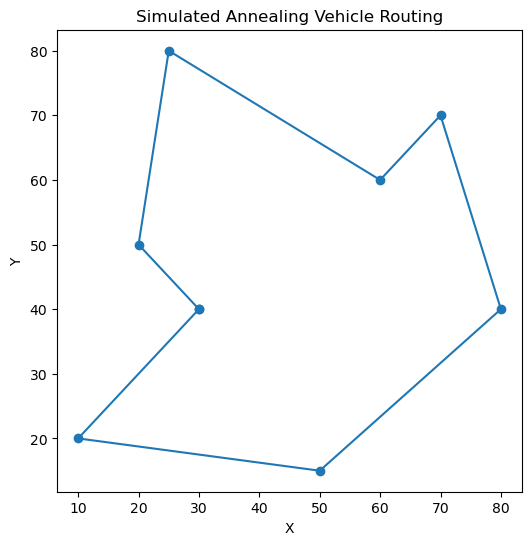

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Example 2D coordinates of locations
locations = np.array([
    [10, 20], [30, 40], [50, 15], [60, 60],
    [20, 50], [80, 40], [25, 80], [70, 70]
])
n_locations = len(locations)

# Calculate total route distance
def total_distance(route):
    dist = 0
    for i in range(len(route)):
        dist += np.linalg.norm(locations[route[i]] - locations[route[(i+1)%n_locations]])
    return dist

# Neighbor: swap two locations
def swap_two(route):
    a, b = np.random.choice(len(route), 2, replace=False)
    new_route = route.copy()
    new_route[a], new_route[b] = new_route[b], new_route[a]
    return new_route

# Simulated Annealing
def simulated_annealing(T_initial=1000, alpha=0.95, max_iter=5000):
    current = np.random.permutation(n_locations)
    current_cost = total_distance(current)
    T = T_initial
    
    for i in range(max_iter):
        neighbor = swap_two(current)
        neighbor_cost = total_distance(neighbor)
        delta = neighbor_cost - current_cost
        
        if delta < 0 or np.random.rand() < np.exp(-delta / T):
            current, current_cost = neighbor, neighbor_cost
        T *= alpha  # cooling
        if T < 1e-3:  # stop if temperature too low
            break
    return current, current_cost

# Run test
best_route, best_cost = simulated_annealing()
print("Best route:", best_route)
print("Total distance:", round(best_cost, 2))

# Plot the route
plt.figure(figsize=(6,6))
route_points = locations[best_route]
route_points = np.vstack((route_points, route_points[0]))  # return to depot
plt.plot(route_points[:,0], route_points[:,1], marker='o')
plt.title("Simulated Annealing Vehicle Routing")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


Exercise 3: Genetic Algorithm for Drone Path Planning

Objective: Minimize path length while avoiding obstacles.

Steps

Chromosome Representation

Fixed-length sequence of waypoints (x, y).

Initial Population

Random feasible paths.

Fitness Function

Path length + high penalty for collision with obstacles.

Genetic Operators

Selection: Tournament selection

Crossover: One-point crossover

Mutation: Random perturbation of waypoints

Constraints

Waypoints within boundaries

Penalize paths intersecting obstacles

Termination

Fixed generations or convergence.

Best path length (with penalty): 48.98


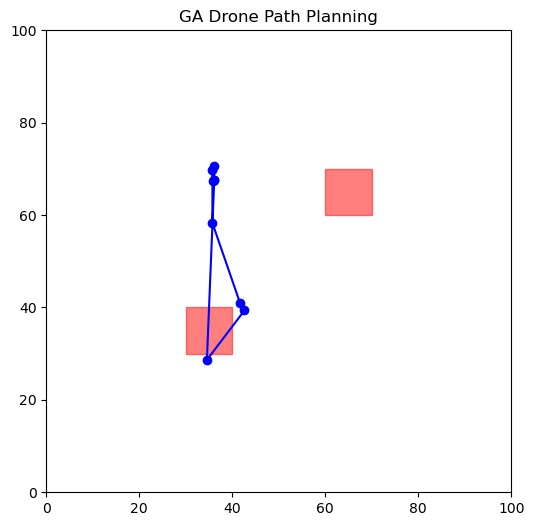

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------
# Map and GA Settings
# ------------------------
map_size = (100, 100)
n_waypoints = 8
population_size = 20
n_generations = 50

# Obstacles: list of rectangles [(x1, y1, x2, y2)]
obstacles = [(30, 30, 40, 40), (60, 60, 70, 70)]

# ------------------------
# Collision Check
# ------------------------
def is_colliding(point):
    x, y = point
    for ox1, oy1, ox2, oy2 in obstacles:
        if ox1 <= x <= ox2 and oy1 <= y <= oy2:
            return True
    return False

# ------------------------
# Fitness Function
# ------------------------
def fitness(path):
    # Path length
    length = sum(np.linalg.norm(path[i] - path[i+1]) for i in range(len(path)-1))
    # Obstacle penalty
    penalty = sum(1000 for p in path if is_colliding(p))
    return length + penalty

# ------------------------
# Initial Population
# ------------------------
population = [np.random.rand(n_waypoints, 2) * map_size[0] for _ in range(population_size)]

# ------------------------
# Selection: Tournament
# ------------------------
def tournament_selection(pop, k=3):
    indices = np.random.choice(len(pop), k, replace=False)  # pick k random indices
    selected = [pop[i] for i in indices]
    selected = sorted(selected, key=fitness)
    return selected[0]

# ------------------------
# Crossover: One-Point
# ------------------------
def one_point_crossover(p1, p2):
    point = np.random.randint(1, n_waypoints-1)
    child = np.vstack((p1[:point], p2[point:]))
    return child

# ------------------------
# Mutation: Random Perturbation
# ------------------------
def mutate(path, mutation_rate=0.2):
    for i in range(len(path)):
        if np.random.rand() < mutation_rate:
            path[i] += np.random.randn(2) * 5  # small change
            path[i] = np.clip(path[i], 0, map_size[0])  # keep within boundaries
    return path

# ------------------------
# Genetic Algorithm Evolution
# ------------------------
for gen in range(n_generations):
    new_population = []
    for _ in range(population_size):
        p1 = tournament_selection(population)
        p2 = tournament_selection(population)
        child = one_point_crossover(p1, p2)
        child = mutate(child)
        new_population.append(child)
    population = new_population

# ------------------------
# Best Path
# ------------------------
best_path = min(population, key=fitness)
print("Best path length (with penalty):", round(fitness(best_path), 2))

# ------------------------
# Visualization
# ------------------------
plt.figure(figsize=(6,6))

# Plot obstacles
for ox1, oy1, ox2, oy2 in obstacles:
    plt.fill([ox1, ox2, ox2, ox1, ox1], [oy1, oy1, oy2, oy2, oy1], color='red', alpha=0.5)

# Plot best path
path_points = np.vstack((best_path, best_path[0]))  # return to start
plt.plot(path_points[:,0], path_points[:,1], marker='o', color='blue')
plt.title("GA Drone Path Planning")
plt.xlim(0, map_size[0])
plt.ylim(0, map_size[1])
plt.show()
